<a href="https://colab.research.google.com/github/isabeljimenezalcantara/clinical-data-science-perg-eda/blob/main/notebooks/EDA_PERG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis of PERG Dataset
Author: Isabel Jimenez Alcantara

Date: 2026-03-31

Objective: Perform data cleaning, visualization, and initial exploration of the PERG dataset to identify clinical patterns in ocular conditions.

### Step 0: Setup Environment

We import necessary libraries for data manipulation and visualization.
We also configure seaborn for cleaner plots and enable inline plotting in Colab.

In [12]:
# Data manipulation
import pandas as pd
import numpy as np
import os

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Settings for better plots
sns.set(style="whitegrid")
%matplotlib inline

# Create folders for derived data and figures
os.makedirs("data", exist_ok=True)
os.makedirs("figures", exist_ok=True)

### Step 1: Load Participants Clinical Data

We load participants' clinical information from the PERG-IOBA dataset directly from PhysioNet.
The dataset contains demographic and clinical information, including:
- Age
- Sex
- Diagnoses
- Visual acuity

We store it in a pandas DataFrame for further exploration.

In [13]:
# Direct URL to participants CSV
participants_url = "https://physionet.org/files/perg-ioba-dataset/1.0.0/csv/participants_info.csv"

# Load into a pandas DataFrame
participants_df = pd.read_csv(participants_url)

# Preview the first rows
participants_df.head()

,id_record,date,age_years,sex,diagnosis1,diagnosis2,diagnosis3,va_re_logMar,va_le_logMar,unilateral,rep_record,comments
0,1,2016-09-15,13,Male,Normal,NaN,NaN,-0.08,0.06,NaN,NaN,NaN
1,2,2005-09-15,13,Female,Congenital stationary night blindness,NaN,NaN,0.18,0.16,NaN,NaN,NaN
2,3,2019-08-08,49,Female,Orbital ischemia,Systemic disorder with ocular manifestations,NaN,0.26,0.00,NaN,Id:0329 - Id:0154 - Id:0049 - Id:0271,NaN
3,4,2004-12-16,43,Female,Retinitis pigmentosa,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,2016-07-13,47,Female,Normal,NaN,NaN,0.10,0.10,NaN,NaN,NaN


### Step 2: Initial Data Inspection

We explore the basic structure of the participants' clinical data:
- Column names and data types
- Missing values
- Descriptive statistics for numerical columns

This helps identify preprocessing needs.

In [14]:
# Inspect columns and data types
participants_df.info()

# Count missing values per column
participants_df.isnull().sum()

# Descriptive statistics for numerical columns
participants_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id_record     336 non-null    int64  
 1   date          336 non-null    object 
 2   age_years     336 non-null    int64  
 3   sex           336 non-null    object 
 4   diagnosis1    336 non-null    object 
 5   diagnosis2    90 non-null     object 
 6   diagnosis3    13 non-null     object 
 7   va_re_logMar  317 non-null    float64
 8   va_le_logMar  317 non-null    float64
 9   unilateral    8 non-null      object 
 10  rep_record    55 non-null     object 
 11  comments      95 non-null     object 
dtypes: float64(2), int64(2), object(8)
memory usage: 31.6+ KB


,id_record,age_years,va_re_logMar,va_le_logMar
count,336.000000,336.000000,317.000000,317.000000
mean,168.500000,37.071429,0.339464,0.320126
std,97.139076,18.284182,0.546977,0.501910
min,1.000000,4.000000,-0.100000,-0.100000
25%,84.750000,21.000000,0.000000,0.000000
50%,168.500000,38.000000,0.160000,0.140000
75%,252.250000,51.000000,0.500000,0.480000
max,336.000000,86.000000,3.000000,3.000000


### Step 3: Visualize Basic Demographics

We explore participants' demographics with simple visualizations:
- Count of participants by sex
- Age distribution

This provides a quick overview of the dataset composition.

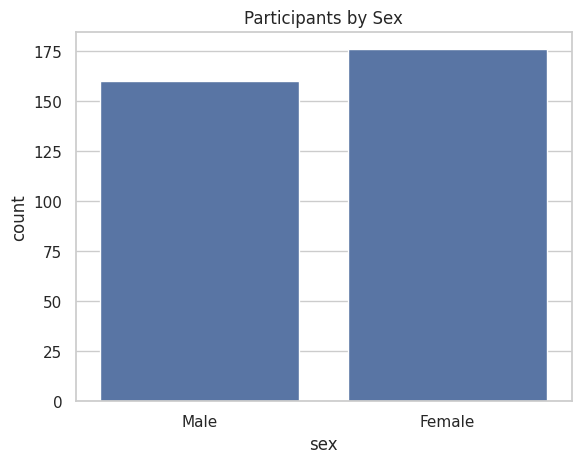

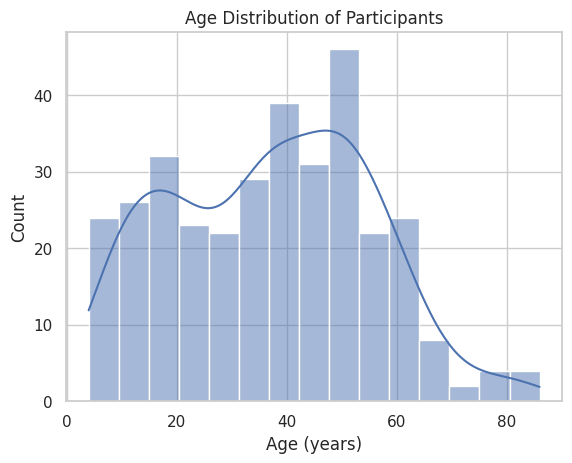

In [15]:
# Distribution of participants by sex
sns.countplot(data=participants_df, x='sex')
plt.title("Participants by Sex")
plt.savefig("figures/participants_by_sex.png")
plt.show()

# Distribution of age
sns.histplot(participants_df['age_years'], bins=15, kde=True)
plt.title("Age Distribution of Participants")
plt.xlabel("Age (years)")
plt.ylabel("Count")
plt.savefig("figures/age_distribution.png")
plt.show()

### Step 4: Explore Diagnoses and Subpopulations

We focus on the primary diagnosis (`diagnosis1`) to explore participant subgroups.
Since some diagnosis names are very long, we display only the top 10 most frequent diagnoses
using horizontal barplots for clarity. We also visualize age and right-eye visual acuity distributions
for these subgroups.

In [21]:
top_diag = participants_df['diagnosis1'].value_counts().nlargest(10).index
df_top_diag = participants_df[participants_df['diagnosis1'].isin(top_diag)]

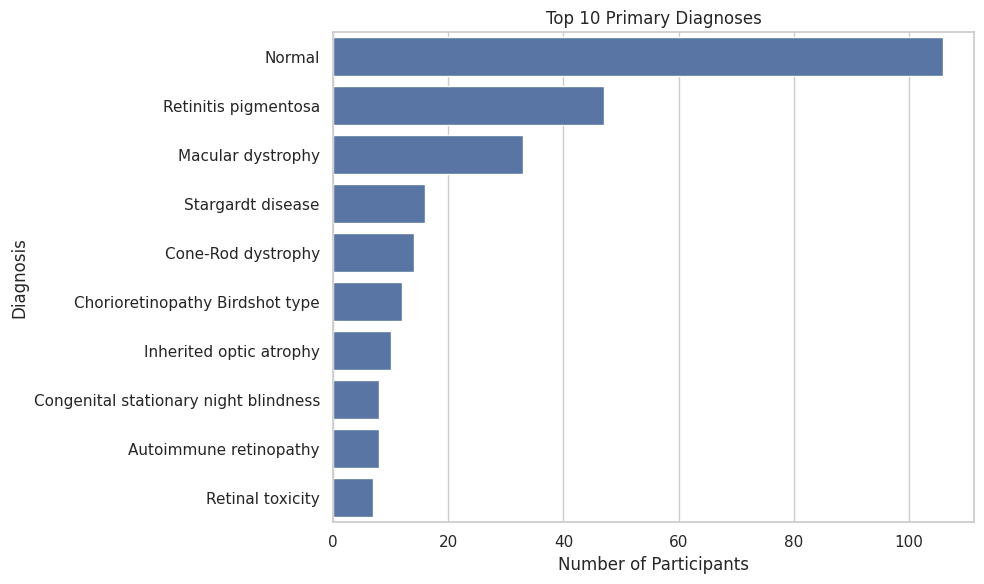

In [23]:
# Count of participants by top 10 diagnosis (horizontal barplot)
plt.figure(figsize=(10,6))
sns.countplot(data=df_top_diag, y='diagnosis1',
              order=df_top_diag['diagnosis1'].value_counts().index)
plt.title("Top 10 Primary Diagnoses")
plt.xlabel("Number of Participants")
plt.ylabel("Diagnosis")
plt.tight_layout()
plt.savefig("figures/top10_diagnoses.png")
plt.show()

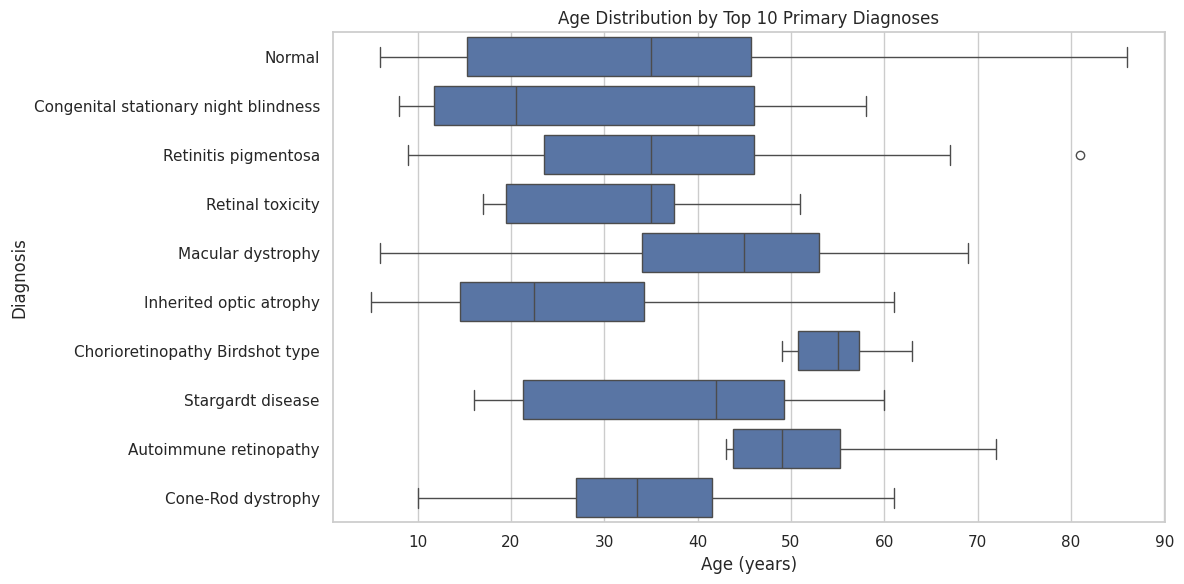

In [24]:
# Age distribution by top 10 diagnosis
plt.figure(figsize=(12,6))
sns.boxplot(data=df_top_diag, y='diagnosis1', x='age_years')
plt.title("Age Distribution by Top 10 Primary Diagnoses")
plt.xlabel("Age (years)")
plt.ylabel("Diagnosis")
plt.tight_layout()
plt.savefig("figures/age_by_top10_diagnoses.png")
plt.show()

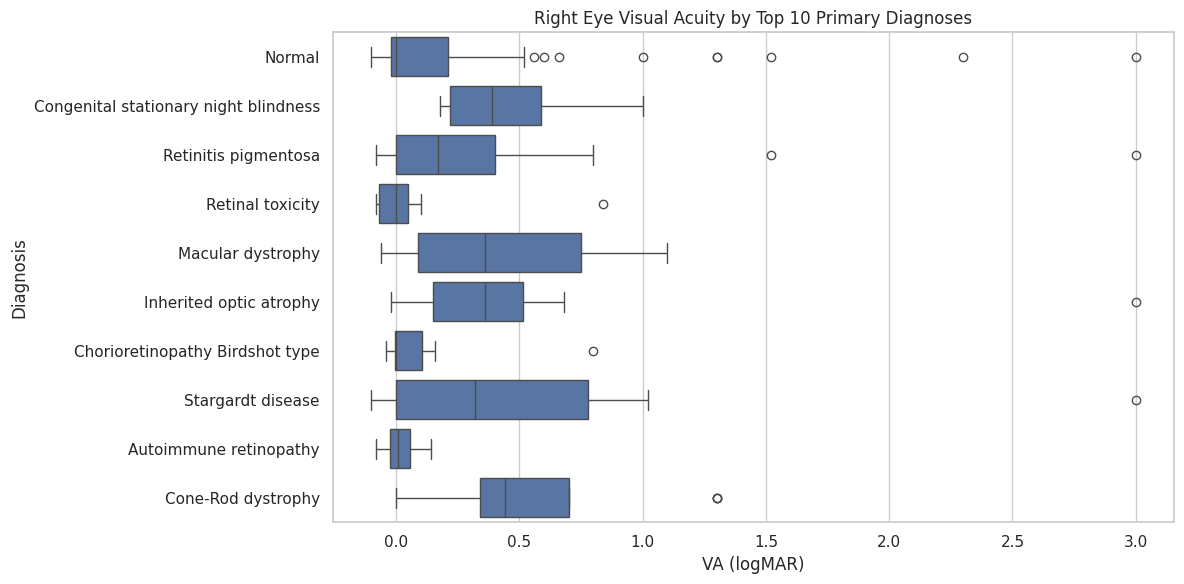

In [25]:
# Right eye visual acuity distribution by top 10 diagnosis
plt.figure(figsize=(12,6))
sns.boxplot(data=df_top_diag, y='diagnosis1', x='va_re_logMar')
plt.title("Right Eye Visual Acuity by Top 10 Primary Diagnoses")
plt.xlabel("VA (logMAR)")
plt.ylabel("Diagnosis")
plt.tight_layout()
plt.savefig("figures/va_re_by_top10_diagnoses.png")
plt.show()

### Step 5: Compare Sex Subpopulations

We explore differences between male and female participants in terms of:
- Age
- Right eye visual acuity (VA)
- Distribution of top 10 primary diagnoses

Horizontal barplots and boxplots are used to maintain readability.

In [26]:
# Use the same top 10 diagnoses from Step 4
df_top_diag = participants_df[participants_df['diagnosis1'].isin(top_diag)]

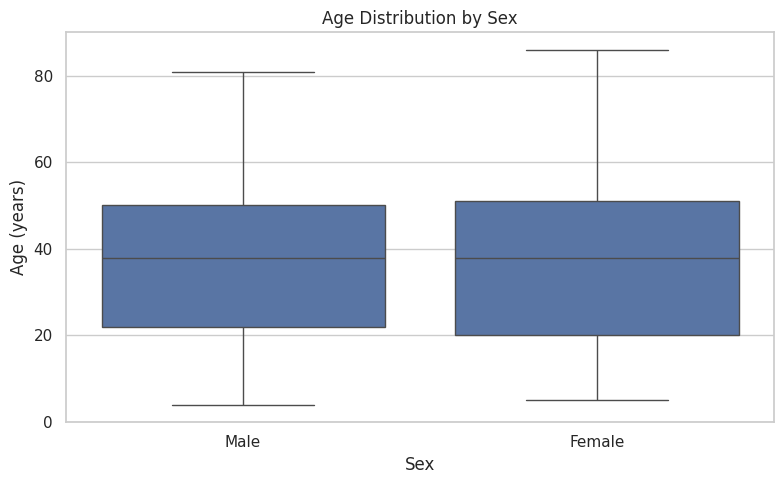

In [27]:
# Age distribution by sex (overall)
plt.figure(figsize=(8,5))
sns.boxplot(data=participants_df, x='sex', y='age_years')
plt.title("Age Distribution by Sex")
plt.xlabel("Sex")
plt.ylabel("Age (years)")
plt.tight_layout()
plt.savefig("figures/age_by_sex.png")
plt.show()

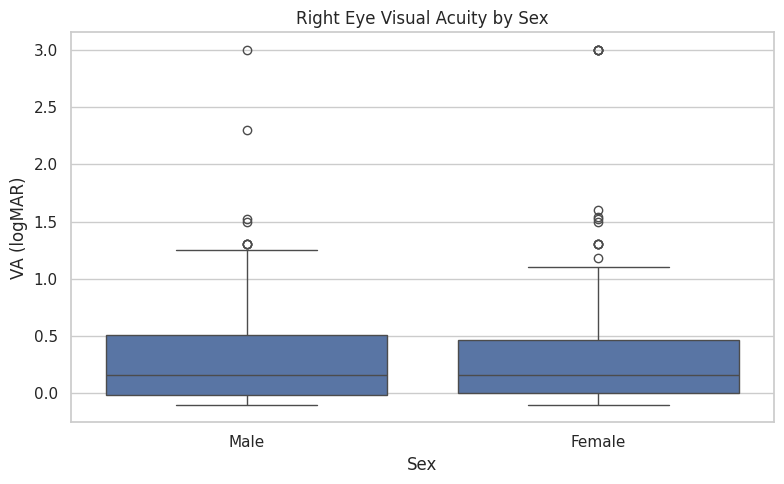

In [28]:
# Right eye visual acuity by sex (overall)
plt.figure(figsize=(8,5))
sns.boxplot(data=participants_df, x='sex', y='va_re_logMar')
plt.title("Right Eye Visual Acuity by Sex")
plt.xlabel("Sex")
plt.ylabel("VA (logMAR)")
plt.tight_layout()
plt.savefig("figures/va_re_by_sex.png")
plt.show()

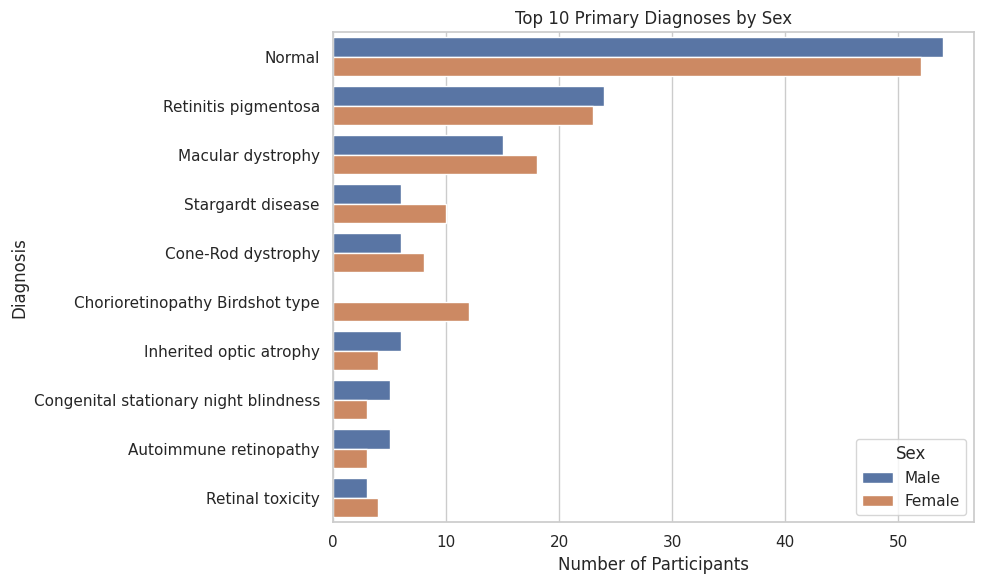

In [29]:
# Count of top 10 diagnoses by sex (horizontal barplot)
plt.figure(figsize=(10,6))
sns.countplot(data=df_top_diag, y='diagnosis1', hue='sex',
              order=df_top_diag['diagnosis1'].value_counts().index)
plt.title("Top 10 Primary Diagnoses by Sex")
plt.xlabel("Number of Participants")
plt.ylabel("Diagnosis")
plt.legend(title="Sex")
plt.tight_layout()
plt.savefig("figures/top10_diagnoses_by_sex.png")
plt.show()

### Step 6: Explore Relationships Between Clinical Variables

We investigate relationships between key clinical variables:
- Age (`age_years`)
- Right eye visual acuity (`va_re_logMar`)
- Left eye visual acuity (`va_le_logMar`)

Each relationship is plotted individually using scatterplots with a regression line
for clarity. A heatmap summarizes the correlations between these variables.

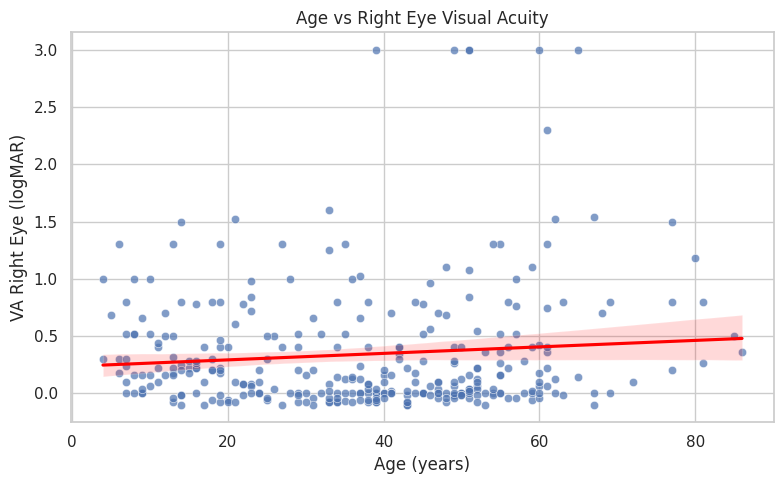

In [32]:
# Age vs Right Eye Visual Acuity
plt.figure(figsize=(8,5))
sns.scatterplot(data=participants_df, x='age_years', y='va_re_logMar', alpha=0.7)
sns.regplot(data=participants_df, x='age_years', y='va_re_logMar', scatter=False, color='red')
plt.title("Age vs Right Eye Visual Acuity")
plt.xlabel("Age (years)")
plt.ylabel("VA Right Eye (logMAR)")
plt.tight_layout()
plt.savefig("figures/age_vs_va_re.png")
plt.show()

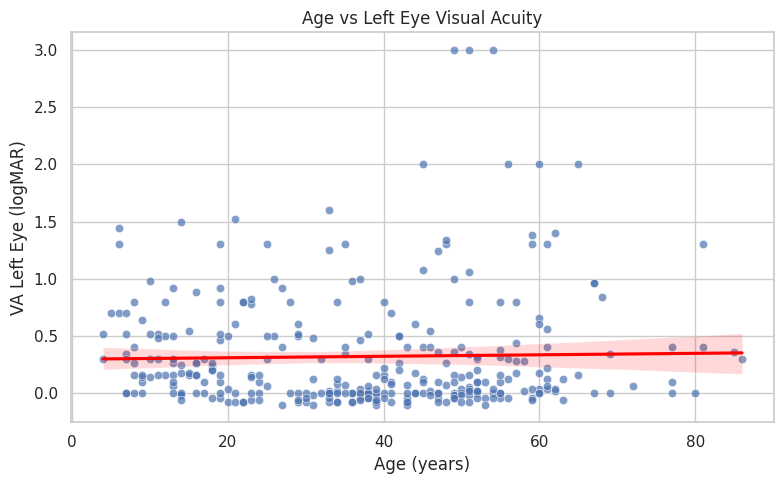

In [33]:
# Age vs Left Eye Visual Acuity
plt.figure(figsize=(8,5))
sns.scatterplot(data=participants_df, x='age_years', y='va_le_logMar', alpha=0.7)
sns.regplot(data=participants_df, x='age_years', y='va_le_logMar', scatter=False, color='red')
plt.title("Age vs Left Eye Visual Acuity")
plt.xlabel("Age (years)")
plt.ylabel("VA Left Eye (logMAR)")
plt.tight_layout()
plt.savefig("figures/age_vs_va_le.png")
plt.show()

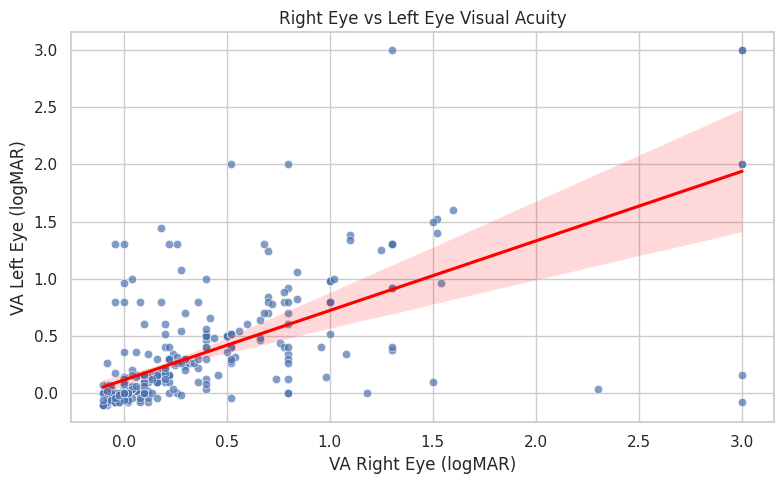

In [34]:
# Right Eye vs Left Eye Visual Acuity
plt.figure(figsize=(8,5))
sns.scatterplot(data=participants_df, x='va_re_logMar', y='va_le_logMar', alpha=0.7)
sns.regplot(data=participants_df, x='va_re_logMar', y='va_le_logMar', scatter=False, color='red')
plt.title("Right Eye vs Left Eye Visual Acuity")
plt.xlabel("VA Right Eye (logMAR)")
plt.ylabel("VA Left Eye (logMAR)")
plt.tight_layout()
plt.savefig("figures/va_re_vs_va_le.png")
plt.show()

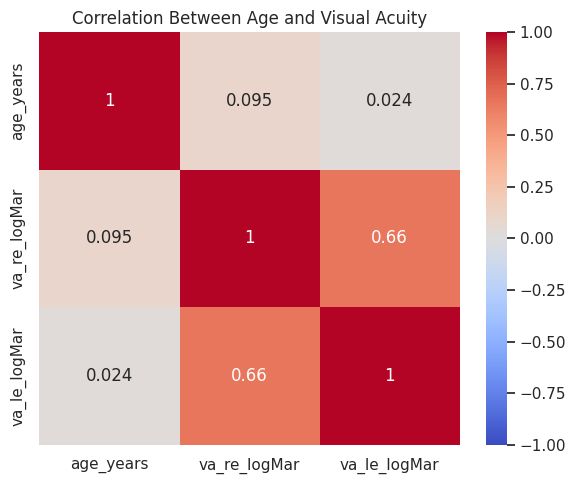

In [35]:
# Correlation Heatmap
plt.figure(figsize=(6,5))
corr = participants_df[['age_years', 'va_re_logMar', 'va_le_logMar']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Between Age and Visual Acuity")
plt.tight_layout()
plt.savefig("figures/corr_age_va.png")
plt.show()

### Step 7: Summary Tables and Key Metrics

In addition to visualizations, we generate descriptive tables to summarize key clinical information:

- Mean, median, and standard deviation of age and visual acuity by sex
- Counts and percentages of participants with reduced vision (e.g., VA > 0.3 logMAR)
- Frequency of top diagnoses overall and by sex

In [36]:
# Descriptive statistics by sex
summary_sex = participants_df.groupby('sex')[['age_years','va_re_logMar','va_le_logMar']].agg(
    ['mean','median','std','min','max']
)
summary_sex

age_years                           va_re_logMar                   \
             mean median        std min max         mean median       std   
sex                                                                         
Female  36.840909   38.0  18.681625   5  86     0.373818   0.16  0.610147   
Male    37.325000   38.0  17.891901   4  81     0.302171   0.16  0.468068   

                 va_le_logMar                             
        min  max         mean median       std  min  max  
sex                                                       
Female -0.1  3.0     0.342970   0.14  0.530467 -0.1  3.0  
Male   -0.1  3.0     0.295329   0.11  0.469438 -0.1  3.0

In [37]:
# Count of participants with reduced vision (logMAR > 0.3)
poor_va_re = (participants_df['va_re_logMar'] > 0.3).sum()
poor_va_le = (participants_df['va_le_logMar'] > 0.3).sum()
total = participants_df.shape[0]

print(f"Right eye: {poor_va_re}/{total} participants ({poor_va_re/total:.1%}) have VA > 0.3")
print(f"Left eye: {poor_va_le}/{total} participants ({poor_va_le/total:.1%}) have VA > 0.3")

Right eye: 106/336 participants (31.5%) have VA > 0.3
Left eye: 104/336 participants (31.0%) have VA > 0.3


In [39]:
# Frequency of top 10 diagnoses overall
top_diag_counts = df_top_diag['diagnosis1'].value_counts().rename_axis('Diagnosis').reset_index(name='Count')
top_diag_counts

,Diagnosis,Count
0,Normal,106
1,Retinitis pigmentosa,47
2,Macular dystrophy,33
3,Stargardt disease,16
4,Cone-Rod dystrophy,14
5,Chorioretinopathy Birdshot type,12
6,Inherited optic atrophy,10
7,Congenital stationary night blindness,8
8,Autoimmune retinopathy,8
9,Retinal toxicity,7


In [40]:
# Top 10 diagnoses by sex
top_diag_sex = df_top_diag.groupby(['diagnosis1','sex']).size().unstack(fill_value=0)
top_diag_sex

sex,Female,Male
diagnosis1,,
Autoimmune retinopathy,3,5
Chorioretinopathy Birdshot type,12,0
Cone-Rod dystrophy,8,6
Congenital stationary night blindness,3,5
Inherited optic atrophy,4,6
Macular dystrophy,18,15
Normal,52,54
Retinal toxicity,4,3
Retinitis pigmentosa,23,24


### Step 8: Finalize Notebook for Portfolio

This final step organizes all previous analyses and ensures reproducibility.
We save derived tables and key metrics, keep all figures, and structure the notebook
for clarity, ready to share on GitHub as a professional Clinical Data Science portfolio project.

In [42]:
# Save key summary tables to data/ for GitHub
summary_sex.to_csv("data/summary_by_sex.csv")
top_diag_counts.to_csv("data/top10_diagnoses.csv", index=False)
top_diag_sex.to_csv("data/top10_diagnoses_by_sex.csv")

### Summary of Key Clinical Metrics

- **By Sex:** mean, median, SD, min, max for age and visual acuity  
- **Reduced Vision:** count and % of participants with VA > 0.3 logMAR  
- **Top 10 Diagnoses:** overall counts and counts by sex

In [43]:
# Display tables in notebook for clarity
print("Descriptive statistics by sex:")
display(summary_sex)

print("Top 10 diagnoses overall:")
display(top_diag_counts)

print("Top 10 diagnoses by sex:")
display(top_diag_sex)

Descriptive statistics by sex:


age_years                           va_re_logMar                   \
             mean median        std min max         mean median       std   
sex                                                                         
Female  36.840909   38.0  18.681625   5  86     0.373818   0.16  0.610147   
Male    37.325000   38.0  17.891901   4  81     0.302171   0.16  0.468068   

                 va_le_logMar                             
        min  max         mean median       std  min  max  
sex                                                       
Female -0.1  3.0     0.342970   0.14  0.530467 -0.1  3.0  
Male   -0.1  3.0     0.295329   0.11  0.469438 -0.1  3.0

Top 10 diagnoses overall:


,Diagnosis,Count
0,Normal,106
1,Retinitis pigmentosa,47
2,Macular dystrophy,33
3,Stargardt disease,16
4,Cone-Rod dystrophy,14
5,Chorioretinopathy Birdshot type,12
6,Inherited optic atrophy,10
7,Congenital stationary night blindness,8
8,Autoimmune retinopathy,8
9,Retinal toxicity,7


Top 10 diagnoses by sex:


sex,Female,Male
diagnosis1,,
Autoimmune retinopathy,3,5
Chorioretinopathy Birdshot type,12,0
Cone-Rod dystrophy,8,6
Congenital stationary night blindness,3,5
Inherited optic atrophy,4,6
Macular dystrophy,18,15
Normal,52,54
Retinal toxicity,4,3
Retinitis pigmentosa,23,24


### Notes for Portfolio

1. **All figures** are saved in `figures/` (scatterplots, boxplots, heatmaps).  
2. **Derived tables** saved in `data/` for reproducibility.  
3. Markdown sections explain:
   - Objective of each step  
   - How graphs support clinical interpretation  
   - Key findings from tables  
4. This notebook can be **directly uploaded to GitHub** with a clean structure:  
